In [2]:
import zipfile
import os
from pathlib import Path

In [3]:
zip_path = r"D:\Velagana_Balaji\data\Orange Dataset.zip"

In [4]:
extract_path = "../dataset"

os.makedirs(extract_path, exist_ok=True)

In [5]:
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully")

Dataset extracted successfully


In [6]:
for root, dirs, files in os.walk(extract_path):
    print(root)

../dataset
../dataset\test
../dataset\test\blackspot
../dataset\test\canker
../dataset\test\fresh
../dataset\test\grenning
../dataset\train
../dataset\train\blackspot
../dataset\train\canker
../dataset\train\fresh
../dataset\train\grenning


In [7]:
from collections import defaultdict

image_count = defaultdict(int)

for split in ['train','test']:

    split_path = os.path.join(
        extract_path,
        split
    )

    for cls in os.listdir(split_path):

        class_path = os.path.join(
            split_path,
            cls
        )

        if os.path.isdir(class_path):

            count = len([
                img for img in os.listdir(class_path)
                if img.lower().endswith(
                    ('.jpg','.jpeg','.png')
                )
            ])

            image_count[
                f"{split}/{cls}"
            ] = count

image_count

defaultdict(int,
            {'train/blackspot': 184,
             'train/canker': 179,
             'train/fresh': 281,
             'train/grenning': 347,
             'test/blackspot': 22,
             'test/canker': 22,
             'test/fresh': 33,
             'test/grenning': 22})

In [8]:
import pandas as pd

df = pd.DataFrame(
    image_count.items(),
    columns=['Class','Count']
)

df

,Class,Count
0,train/blackspot,184
1,train/canker,179
2,train/fresh,281
3,train/grenning,347
4,test/blackspot,22
5,test/canker,22
6,test/fresh,33
7,test/grenning,22


Class Distribution Analysis

In [9]:
df['Percentage'] = (
    df['Count'] /
    df['Count'].sum()
) * 100

df

,Class,Count,Percentage
0,train/blackspot,184,16.880734
1,train/canker,179,16.422018
2,train/fresh,281,25.779817
3,train/grenning,347,31.834862
4,test/blackspot,22,2.018349
5,test/canker,22,2.018349
6,test/fresh,33,3.027523
7,test/grenning,22,2.018349


Visualization of class distribution

Text(0, 0.5, 'Image Count')

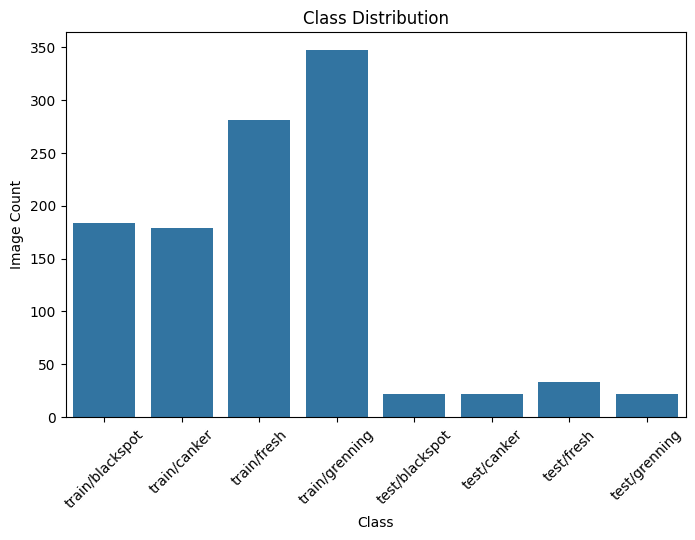

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Class',
    y='Count'
)

plt.xticks(rotation=45)

plt.title(
    "Class Distribution"
)

plt.ylabel(
    "Image Count"
)


Training and testing splits preserve similar proportions.
The "train/grenning" class dominates the dataset,which may influence model learning.

Image Dimension Analysis

In [11]:
from PIL import Image
import os

widths = []
heights = []

dataset_path = "../dataset"

for split in ['train','test']:

    split_path = os.path.join(
        dataset_path,
        split
    )

    for cls in os.listdir(split_path):

        class_path = os.path.join(
            split_path,
            cls
        )

        for img_name in os.listdir(class_path):

            img_path = os.path.join(
                class_path,
                img_name
            )

            try:

                img = Image.open(img_path)

                w,h = img.size

                widths.append(w)
                heights.append(h)

            except:
                pass

In [12]:
import pandas as pd

dimension_df = pd.DataFrame({

    'Width':widths,
    'Height':heights

})

dimension_df.describe()

,Width,Height
count,1090.000000,1090.000000
mean,669.022018,659.438532
std,211.551046,224.984294
min,144.000000,138.000000
25%,454.500000,400.000000
50%,800.000000,800.000000
75%,800.000000,800.000000
max,800.000000,800.000000


Plot Image Size Distribution

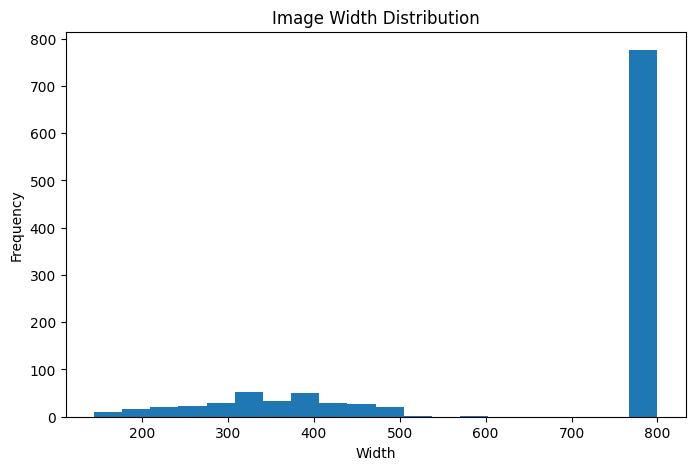

In [13]:
plt.figure(figsize=(8,5))

plt.hist(
    widths,
    bins=20
)

plt.xlabel("Width")

plt.ylabel("Frequency")

plt.title(
    "Image Width Distribution"
)

plt.show()

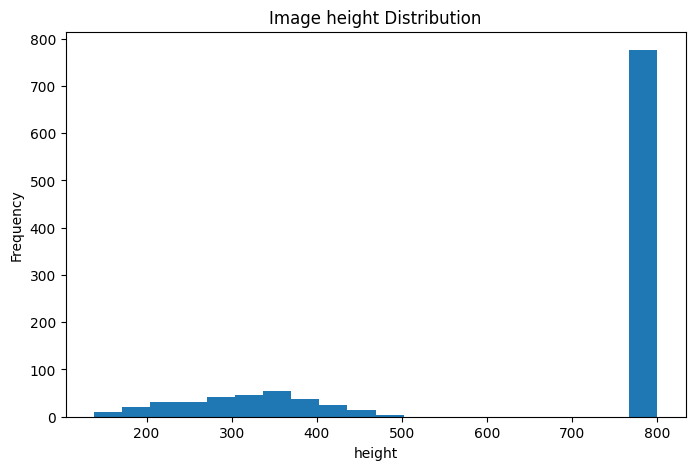

In [14]:
plt.figure(figsize=(8,5))

plt.hist(
    heights,
    bins=20
)

plt.xlabel("height")

plt.ylabel("Frequency")

plt.title(
    "Image height Distribution"
)

plt.show()

Corrupted Image Detection

In [15]:
corrupt = []

for split in ['train','test']:

    split_path = os.path.join(
        dataset_path,
        split
    )

    for cls in os.listdir(split_path):

        class_path = os.path.join(
            split_path,
            cls
        )

        for img in os.listdir(class_path):

            path = os.path.join(
                class_path,
                img
            )

            try:

                Image.open(path).verify()

            except:

                corrupt.append(path)

print(
    "Corrupt Images:",
    len(corrupt)
)

Corrupt Images: 0


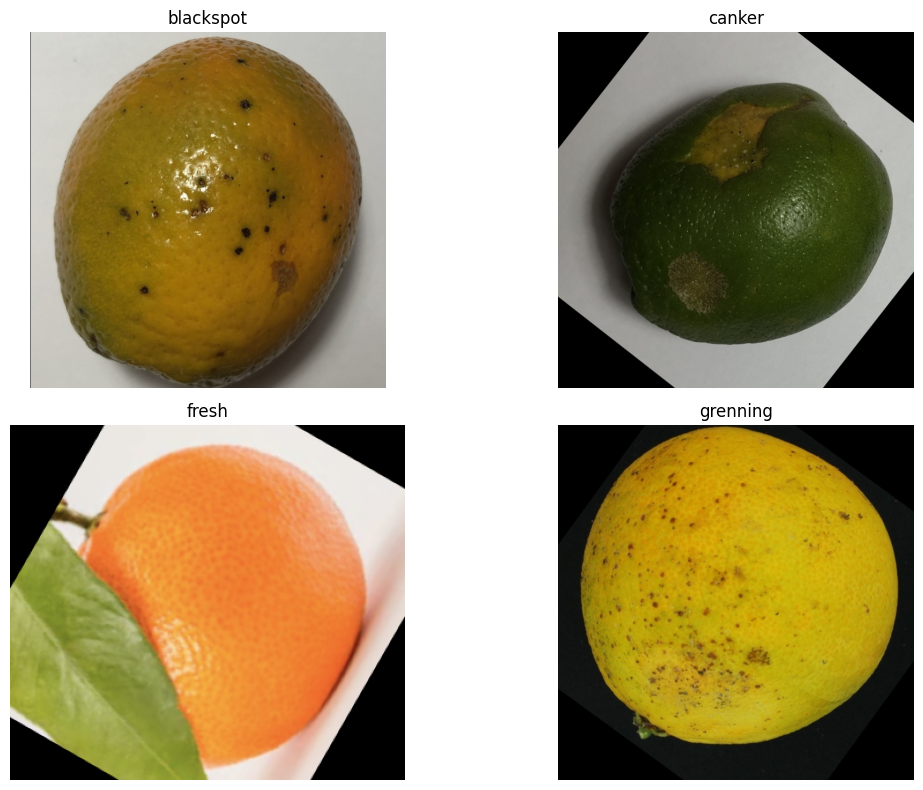

In [16]:
import random
import matplotlib.pyplot as plt
from PIL import Image

dataset_path = "../dataset/train"

classes = os.listdir(dataset_path)

plt.figure(figsize=(12,8))

for i,cls in enumerate(classes):

    class_path = os.path.join(
        dataset_path,
        cls
    )

    img_name = random.choice(
        os.listdir(class_path)
    )

    img_path = os.path.join(
        class_path,
        img_name
    )

    img = Image.open(img_path)

    plt.subplot(2,2,i+1)

    plt.imshow(img)

    plt.title(cls)

    plt.axis('off')

plt.tight_layout()

plt.show()